Extracting parameters from D:\Work_data\Notification_evoked_response\Data_at_IITJ\sub010\EEG\sub010-exp2.vhdr...
Setting channel info structure...


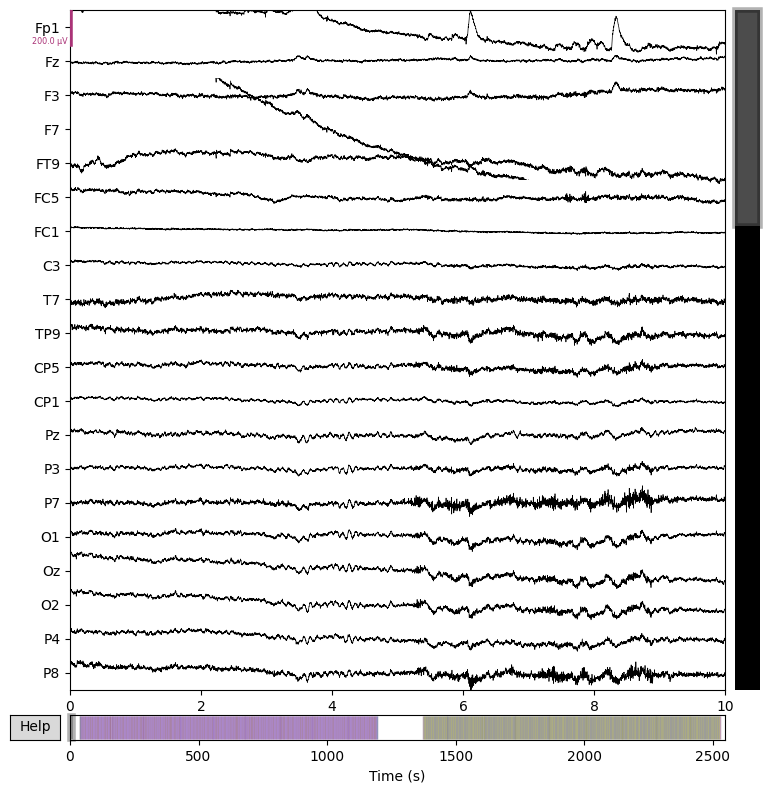

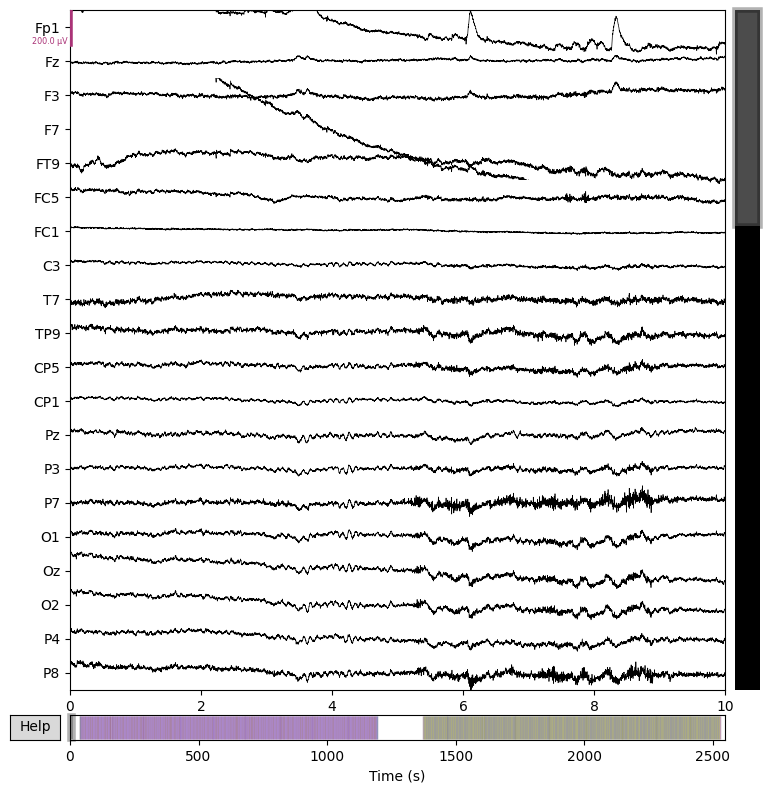

In [31]:
import matplotlib.pyplot as plt
import numpy as np
#import pandas as pd

import mne


raw_file = r"D:\Work_data\Notification_evoked_response\Data_at_IITJ\sub010\EEG\sub010-exp2.vhdr"
raw = mne.io.read_raw_brainvision(raw_file, preload=False)
raw.crop(tmin=300) 
raw.plot(scalings=dict(eeg=1e-4))


In [21]:
info = raw.info
print(info.keys())
print(info['ch_names'])

dict_keys(['acq_pars', 'acq_stim', 'ctf_head_t', 'description', 'dev_ctf_t', 'dig', 'experimenter', 'utc_offset', 'device_info', 'file_id', 'highpass', 'hpi_subsystem', 'kit_system_id', 'helium_info', 'line_freq', 'lowpass', 'meas_date', 'meas_id', 'proj_id', 'proj_name', 'subject_info', 'xplotter_layout', 'gantry_angle', 'bads', 'chs', 'comps', 'events', 'hpi_meas', 'hpi_results', 'projs', 'proc_history', 'custom_ref_applied', 'sfreq', 'dev_head_t', 'ch_names', 'nchan'])
['Fp1', 'Fz', 'F3', 'F7', 'FT9', 'FC5', 'FC1', 'C3', 'T7', 'TP9', 'CP5', 'CP1', 'Pz', 'P3', 'P7', 'O1', 'Oz', 'O2', 'P4', 'P8', 'TP10', 'CP6', 'CP2', 'Cz', 'C4', 'T8', 'FT10', 'FC6', 'FC2', 'F4', 'F8', 'Fp2', 'AF7', 'AF3', 'AFz', 'F1', 'F5', 'FT7', 'FC3', 'C1', 'C5', 'TP7', 'CP3', 'P1', 'P5', 'PO7', 'PO3', 'POz', 'PO4', 'PO8', 'P6', 'P2', 'CPz', 'CP4', 'TP8', 'C6', 'C2', 'FC4', 'FT8', 'F6', 'AF8', 'AF4', 'F2']


In [3]:
print(raw)
print(raw.info)

<RawBrainVision | Sub010-exp2.eeg, 63 x 2848120 (2848.1 s), ~55 kB, data not loaded>
<Info | 7 non-empty values
 bads: []
 ch_names: Fp1, Fz, F3, F7, FT9, FC5, FC1, C3, T7, TP9, CP5, CP1, Pz, P3, ...
 chs: 63 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 280.0 Hz
 meas_date: 2024-06-08 14:00:28 UTC
 nchan: 63
 projs: []
 sfreq: 1000.0 Hz
>


Effective window size : 2.048 (s)
Plotting power spectral density (dB=True).


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_4068\3186301473.py:1: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw.compute_psd(fmax=50).plot(picks="data", exclude="bads", amplitude=False)
c:\Users\PRAKASH\AppData\Local\anaconda3\envs\EEG_analysis\Lib\site-packages\mne\viz\utils.py:167: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


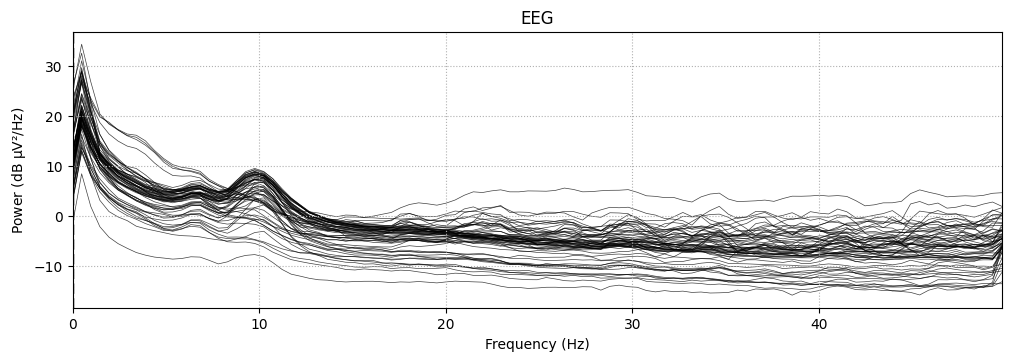

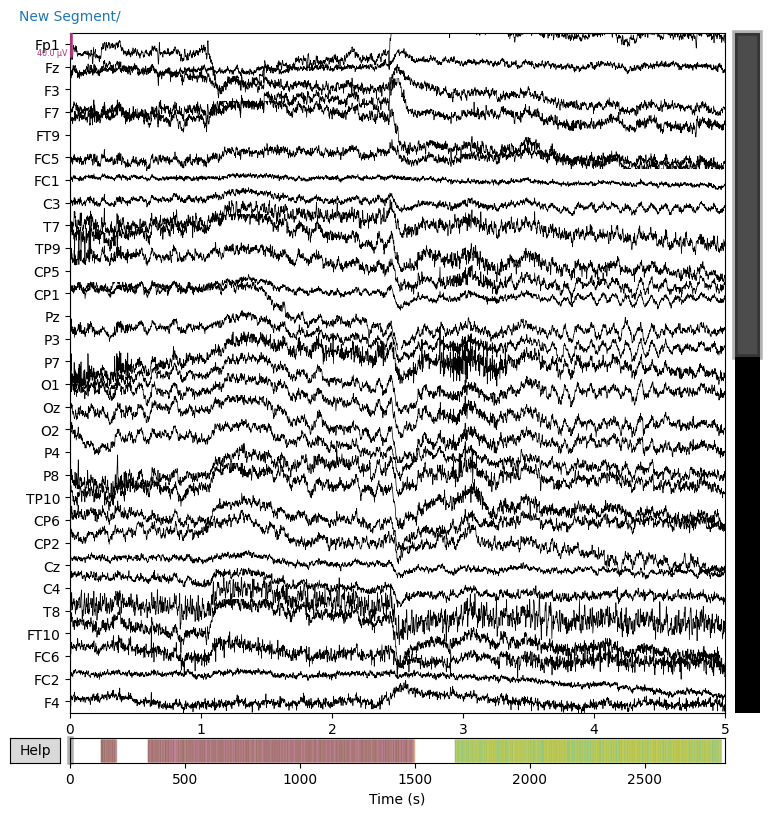

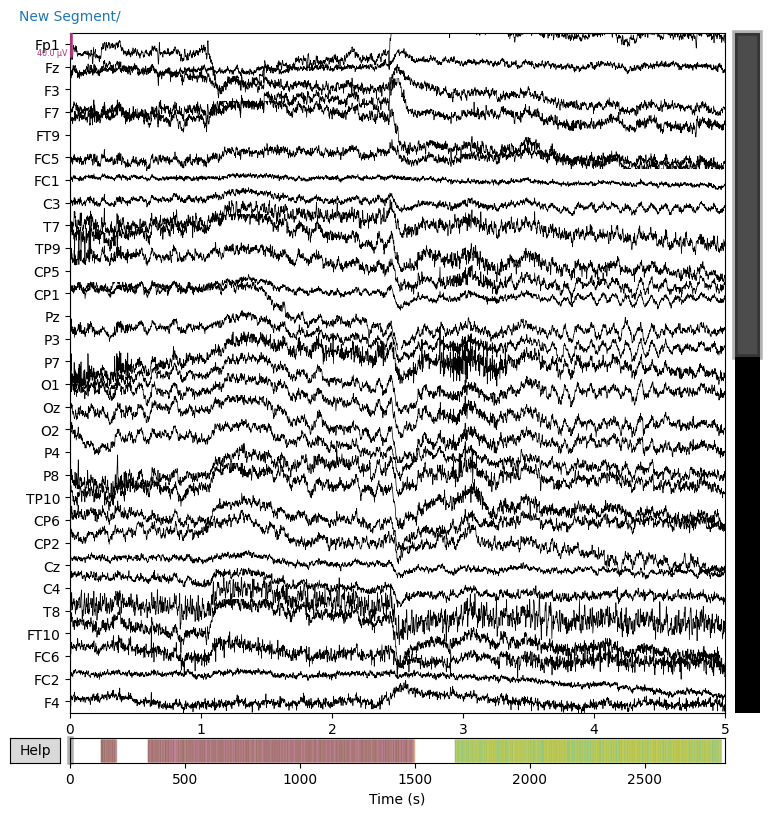

In [4]:
raw.compute_psd(fmax=50).plot(picks="data", exclude="bads", amplitude=False)
raw.plot(duration=5, n_channels=30)

In [5]:
events,event_dict = mne.events_from_annotations(raw)
print(event_dict)

Used Annotations descriptions: ['New Segment/', 'Stimulus/S 11', 'Stimulus/S 12', 'Stimulus/S 13', 'Stimulus/S 14', 'Stimulus/S 15', 'Stimulus/S 21', 'Stimulus/S 24', 'Stimulus/S 25']
{'New Segment/': 99999, 'Stimulus/S 11': 11, 'Stimulus/S 12': 12, 'Stimulus/S 13': 13, 'Stimulus/S 14': 14, 'Stimulus/S 15': 15, 'Stimulus/S 21': 21, 'Stimulus/S 24': 24, 'Stimulus/S 25': 25}


Not setting metadata
952 matching events found
Setting baseline interval to [-0.3, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Loading data for 952 events and 1001 original time points ...
0 bad epochs dropped


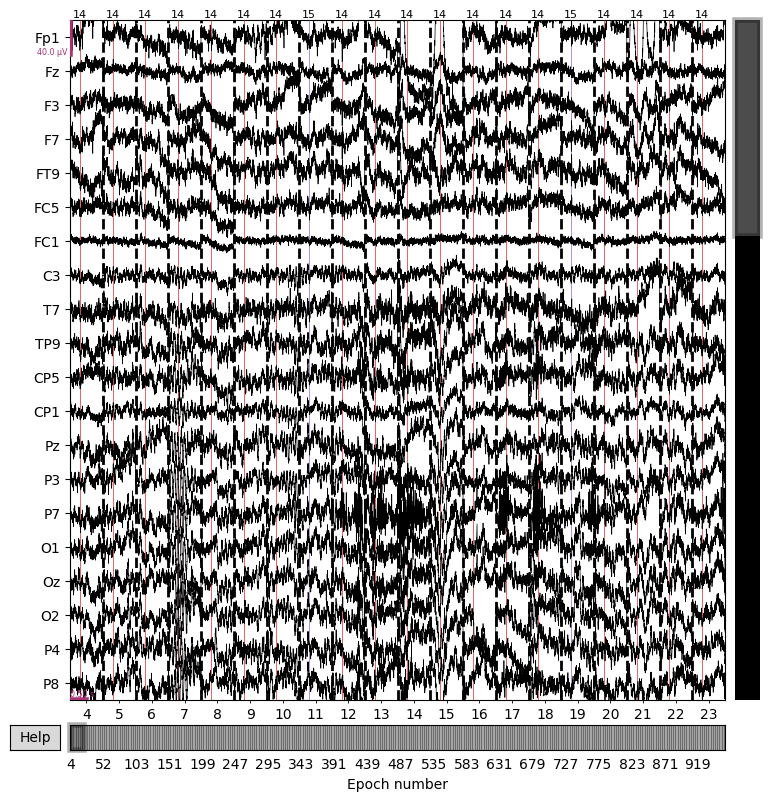

In [6]:
B1_epochs = mne.Epochs(raw, events, event_id=[14,15], tmin=-0.3, tmax=0.7, preload=True)
fig = B1_epochs.plot(events=events
                  )

In [7]:
devi_eps = B1_epochs['15'].average()
sta_eps = B1_epochs["14"].average()

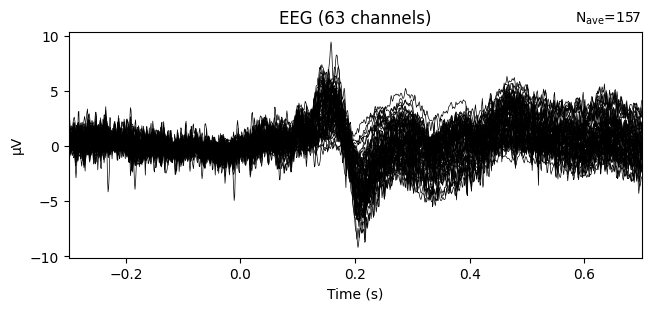

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_4068\3372033010.py:2: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  fig2 = sta_eps.plot(spatial_colors=True)


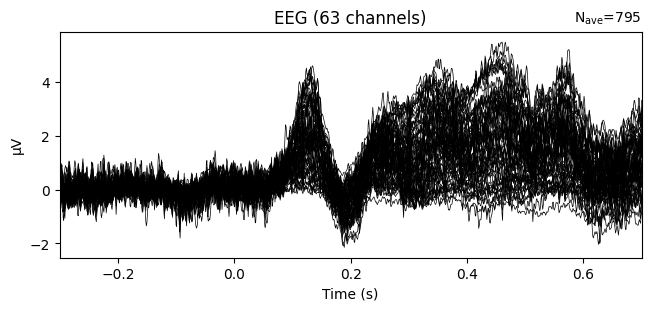

In [8]:
fig1 = devi_eps.plot()
fig2 = sta_eps.plot(spatial_colors=True)

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_4068\3282695542.py:2: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  evk.plot(gfp=True, spatial_colors=True, ylim=dict(eeg=[-12, 12]))


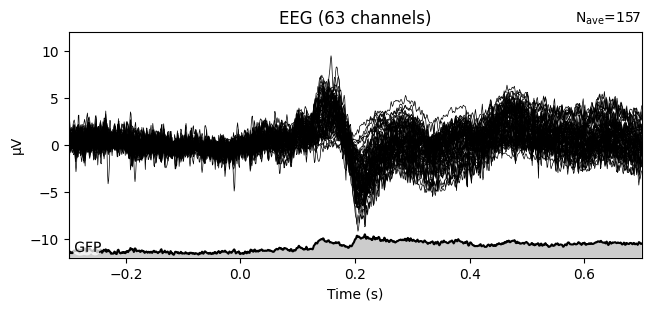

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_4068\3282695542.py:2: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  evk.plot(gfp=True, spatial_colors=True, ylim=dict(eeg=[-12, 12]))


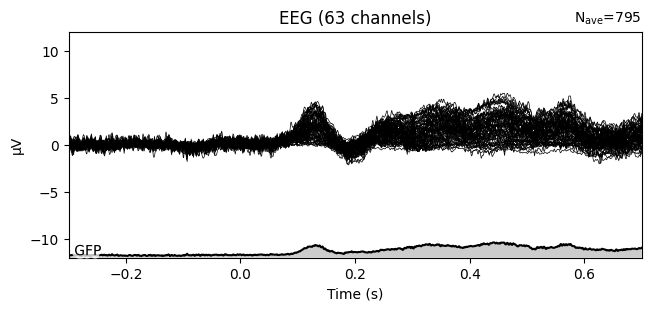

In [9]:
for evk in (devi_eps, sta_eps):
    evk.plot(gfp=True, spatial_colors=True, ylim=dict(eeg=[-12, 12]))

combining channels using "mean"
combining channels using "mean"


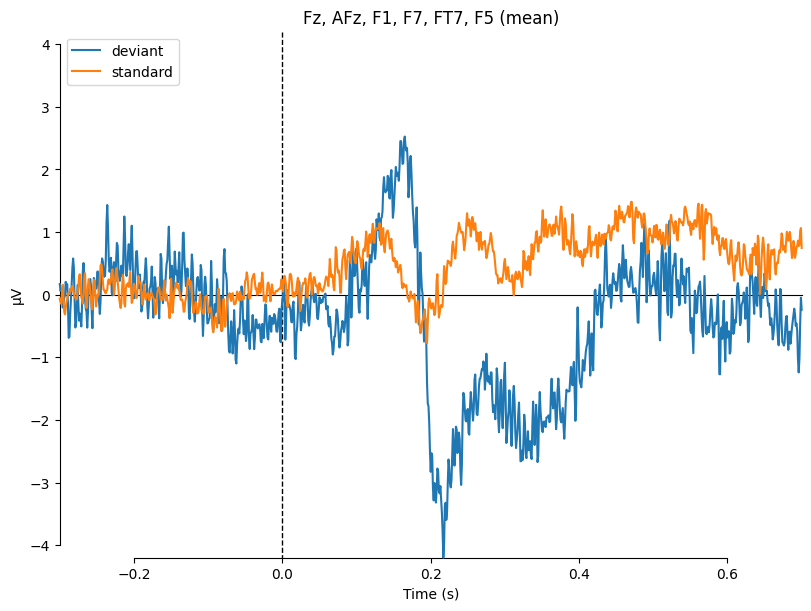

[<Figure size 800x600 with 1 Axes>]

In [10]:
# Campare the two contidition of deviant vs standard tone  
evokeds = dict(deviant=devi_eps, standard=sta_eps)
picks = [1,34,35,3,37,36]
mne.viz.plot_compare_evokeds(evokeds, picks=picks, combine="mean")

combining channels using "mean"
combining channels using "mean"


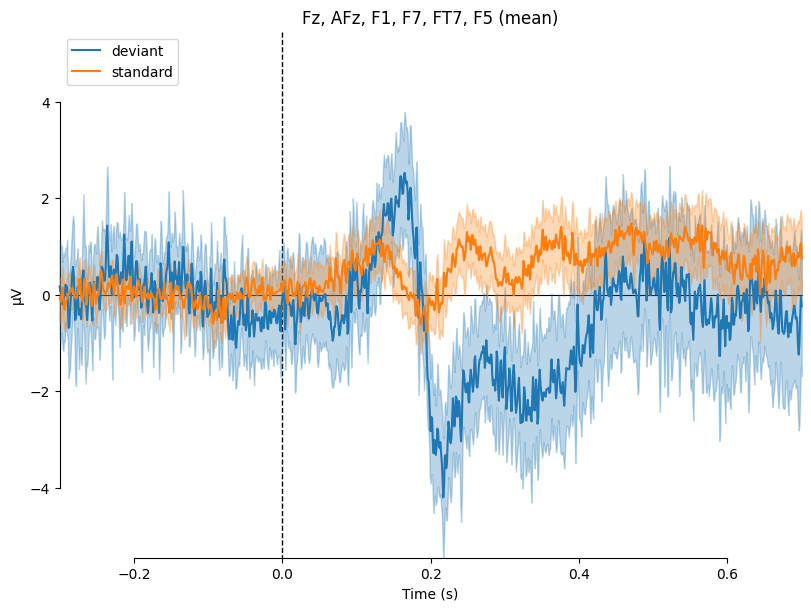

[<Figure size 800x600 with 1 Axes>]

In [11]:
# Campare the two contidition of deviant vs standard tone  with confidence interval 
evokeds = dict(
    deviant=list(B1_epochs['15'].iter_evoked()),
    standard=list(B1_epochs['14'].iter_evoked()),
    
)
mne.viz.plot_compare_evokeds(evokeds, combine="mean", picks=picks)

combining channels using "mean"


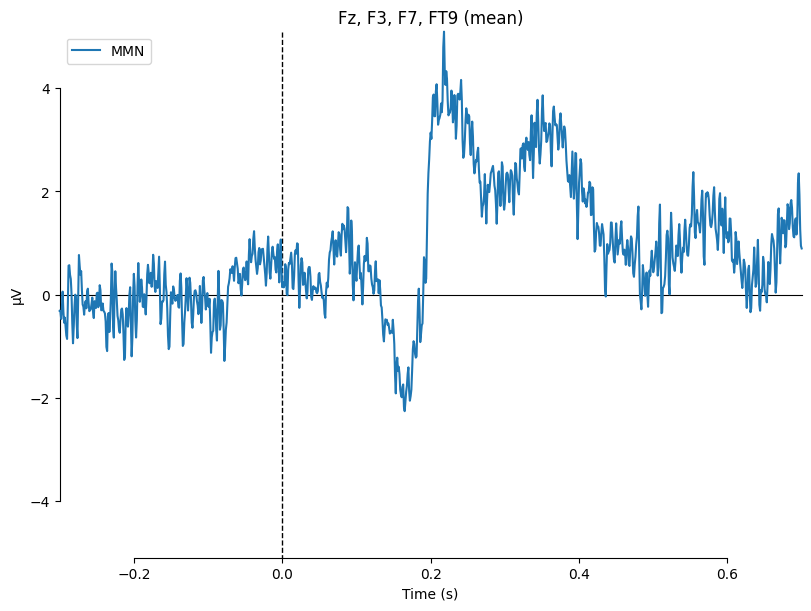

[<Figure size 800x600 with 1 Axes>]

In [12]:
MMN_erp = mne.combine_evoked([ devi_eps,sta_eps], weights=[-1, 1])
# Campare the two contidition of deviant vs standard tone  
evokeds = dict(MMN = MMN_erp)
picks = [n for n in range(1, 5)]
mne.viz.plot_compare_evokeds(evokeds, picks=picks, combine="mean")

combining channels using "mean"
combining channels using "mean"


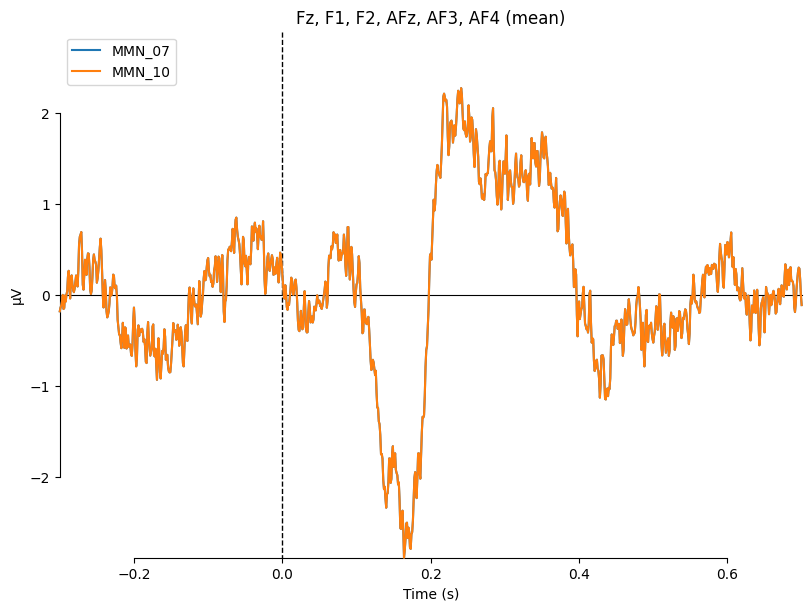

[<Figure size 800x600 with 1 Axes>]

In [25]:
MMN_erp1 = mne.combine_evoked([ devi_eps,sta_eps], weights=[-1, 1])
# Campare the two contidition of deviant vs standard tone  
evokeds = dict(MMN_07 = MMN_erp,MMN_10 =MMN_erp1 )
#picks = [n for n in range(1, 5)]
picks= ['Fz','F1','F2','AFz','AF3','AF4']
mne.viz.plot_compare_evokeds(evokeds, picks=picks, combine="mean")

Extracting parameters from D:\Work_data\Notification_evoked_response\Data_at_IITJ\sub010\EEG\sub010-exp2.vhdr...
Setting channel info structure...
Reading 0 ... 2848119  =      0.000 ...  2848.119 secs...
Using matplotlib as 2D backend.


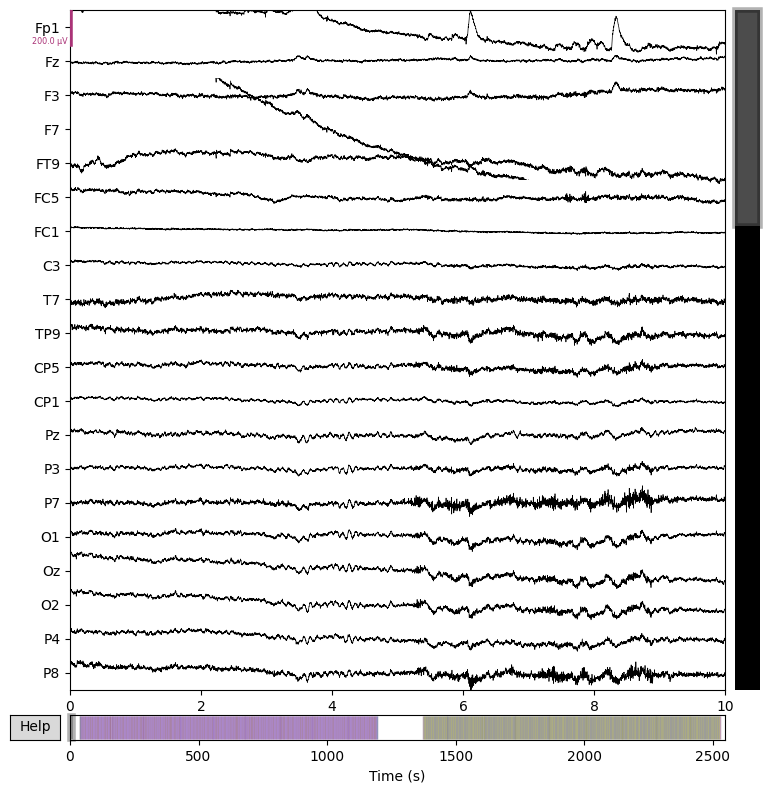

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 33001 samples (33.001 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    2.0s


Used Annotations descriptions: ['Stimulus/S 11', 'Stimulus/S 12', 'Stimulus/S 13', 'Stimulus/S 14', 'Stimulus/S 15', 'Stimulus/S 21', 'Stimulus/S 24', 'Stimulus/S 25']
Not setting metadata
900 matching events found
Setting baseline interval to [-0.3, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 900 events and 1001 original time points ...
0 bad epochs dropped


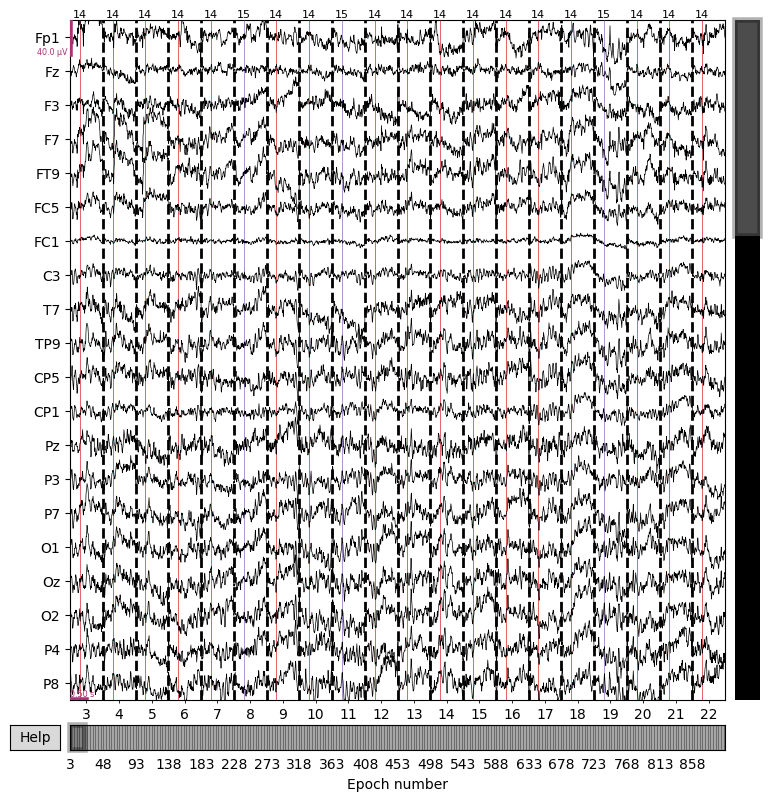

Not setting metadata
900 matching events found
Setting baseline interval to [-0.3, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 900 events and 1001 original time points ...
0 bad epochs dropped


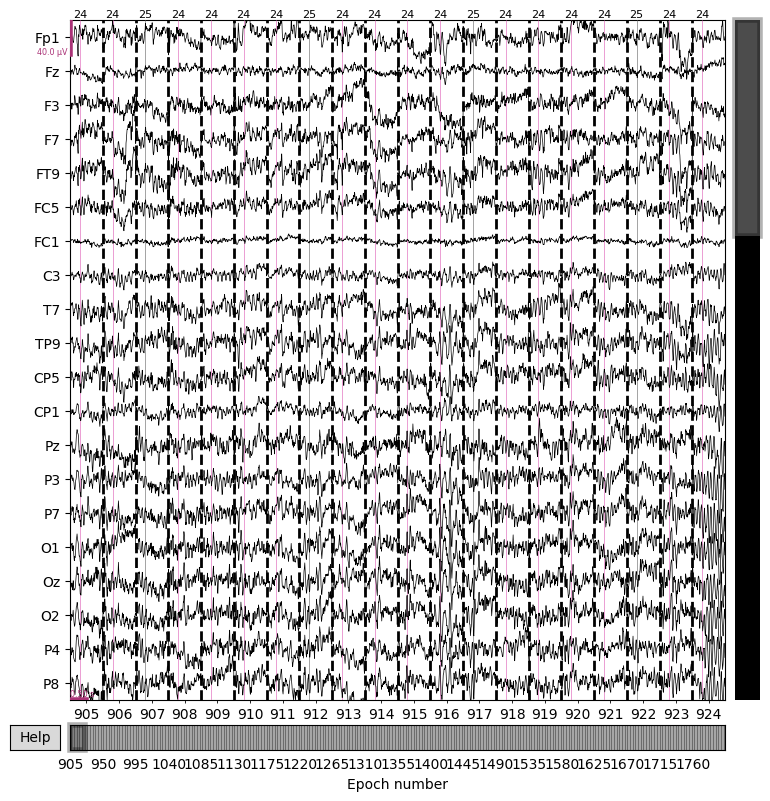

150 750 150 750
combining channels using "mean"


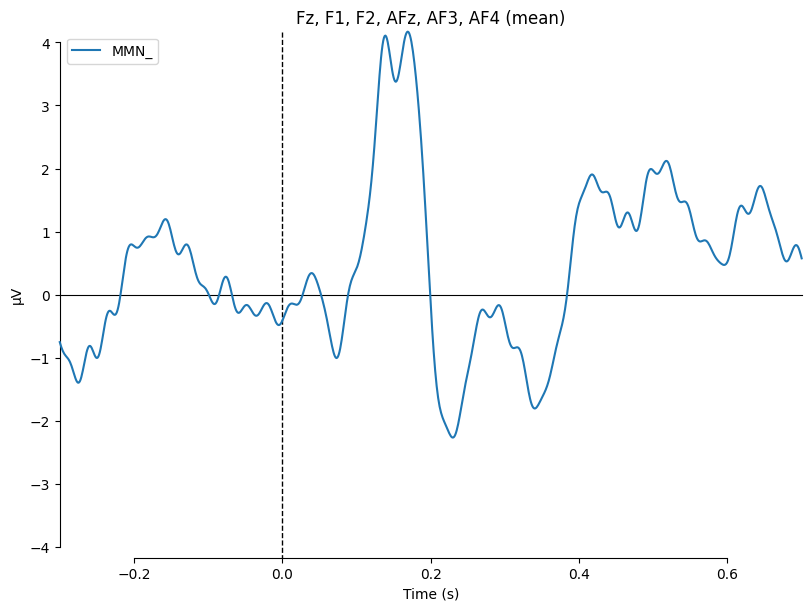

[<Figure size 800x600 with 1 Axes>]

In [1]:
import matplotlib.pyplot as plt
import numpy as np
#import pandas as pd

import mne


raw_file = r"D:\Work_data\Notification_evoked_response\Data_at_IITJ\sub010\EEG\sub010-exp2.vhdr"
raw = mne.io.read_raw_brainvision(raw_file, preload=True)
raw.crop(tmin=300) 
raw.plot(scalings=dict(eeg=1e-4))

raw.filter(l_freq=0.1,h_freq=40)
events,event_dict = mne.events_from_annotations(raw)

B1_epochs = mne.Epochs(raw, events, event_id=[14,15], tmin=-0.3, tmax=0.7, preload=True)
fig = B1_epochs.plot(events=events
                  )
B1_devi_eps = B1_epochs['15'].average()
B1_sta_eps = B1_epochs["14"].average()
B1_MMN_erp = mne.combine_evoked([ B1_devi_eps,B1_sta_eps], weights=[1,-1])

B2_epochs = mne.Epochs(raw, events, event_id=[24,25], tmin=-0.3, tmax=0.7, preload=True)

fig = B2_epochs.plot(events=events
                  )
B2_devi_eps = B2_epochs['25'].average()
B2_sta_eps = B2_epochs["24"].average()
print(len(B2_epochs['25']),len(B2_epochs['24']),len(B1_epochs['15']),len(B1_epochs['14']))
B2_MMN_erp = mne.combine_evoked([ B2_devi_eps,B2_sta_eps], weights=[1,-1])
#MMN_erp1 = mne.combine_evoked([ devi_eps,sta_eps], weights=[1, -1])
#MMN_er = mne.combine_evoked([ MMN_erp1,MMN_erp], weights=[1, -1])
# Campare the two contidition of deviant vs standard tone  

S10_MMN_erp = mne.combine_evoked([ B1_MMN_erp,B2_MMN_erp], weights=[1,-1])
evokeds = dict(MMN_ =S10_MMN_erp)
#picks = [n for n in range(1, 5)]
picks= ['Fz','F1','F2','AFz','AF3','AF4']
mne.viz.plot_compare_evokeds(evokeds, picks=picks, combine="mean")

Extracting parameters from D:\Work_data\Notification_evoked_response\Data_at_IITJ\sub007\EEG\sub007_exp2.vhdr...
Setting channel info structure...
Reading 0 ... 2485059  =      0.000 ...  2485.059 secs...


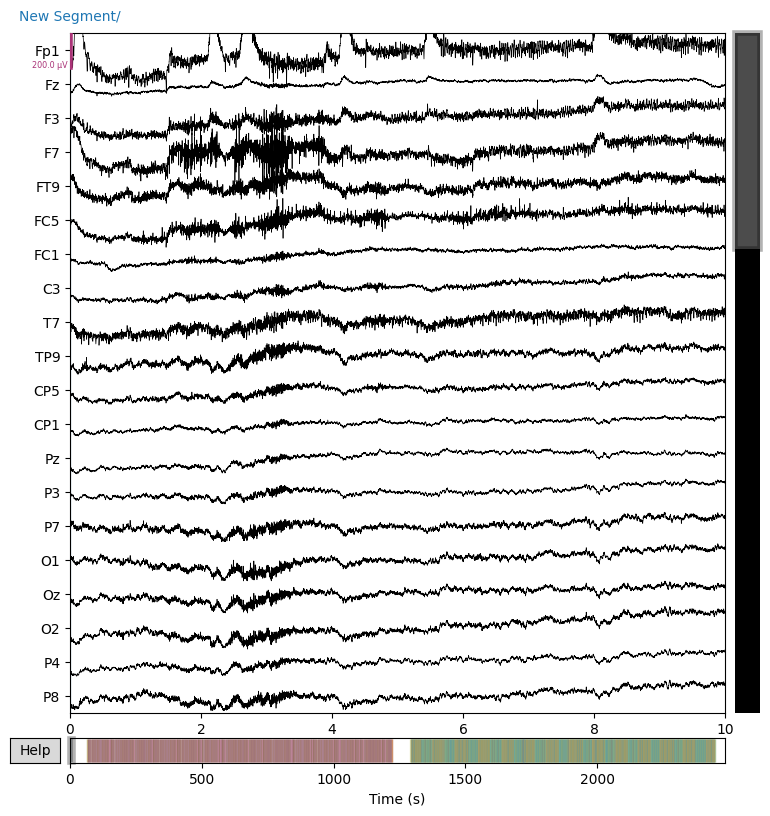

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 33001 samples (33.001 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    2.0s


Used Annotations descriptions: ['New Segment/', 'Stimulus/S 11', 'Stimulus/S 12', 'Stimulus/S 13', 'Stimulus/S 14', 'Stimulus/S 15', 'Stimulus/S 18', 'Stimulus/S 21', 'Stimulus/S 24', 'Stimulus/S 25', 'Stimulus/S 26']
Not setting metadata
900 matching events found
Setting baseline interval to [-0.3, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 900 events and 1001 original time points ...
0 bad epochs dropped


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_17824\2319327581.py:16: RuntimeWarning: More events than default colors available. You should pass a list of unique colors.
  fig = B1_epochs.plot(events=events


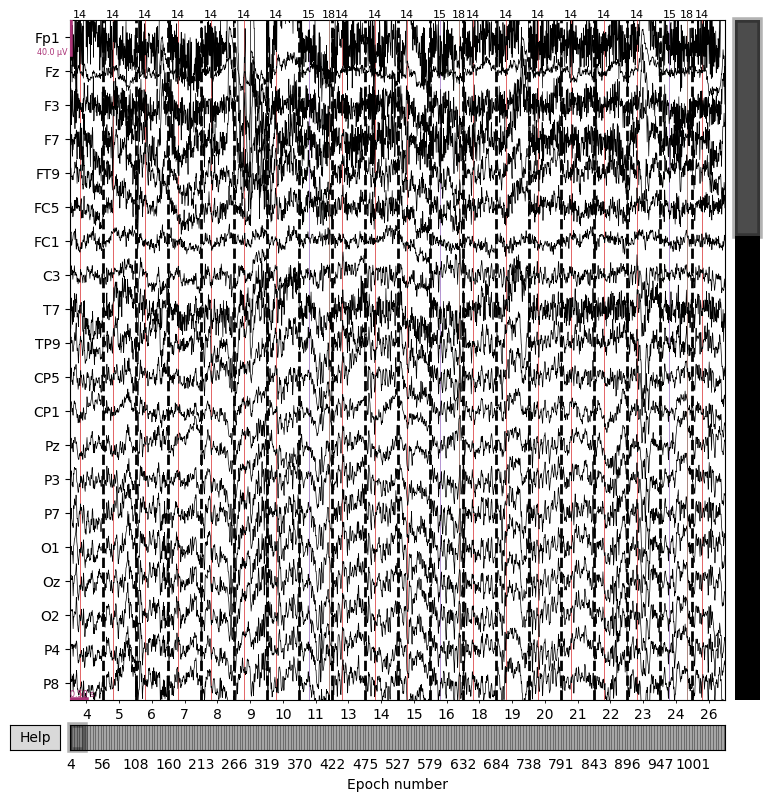

Not setting metadata
900 matching events found
Setting baseline interval to [-0.3, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 900 events and 1001 original time points ...
0 bad epochs dropped


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_17824\2319327581.py:24: RuntimeWarning: More events than default colors available. You should pass a list of unique colors.
  fig = B2_epochs.plot(events=events


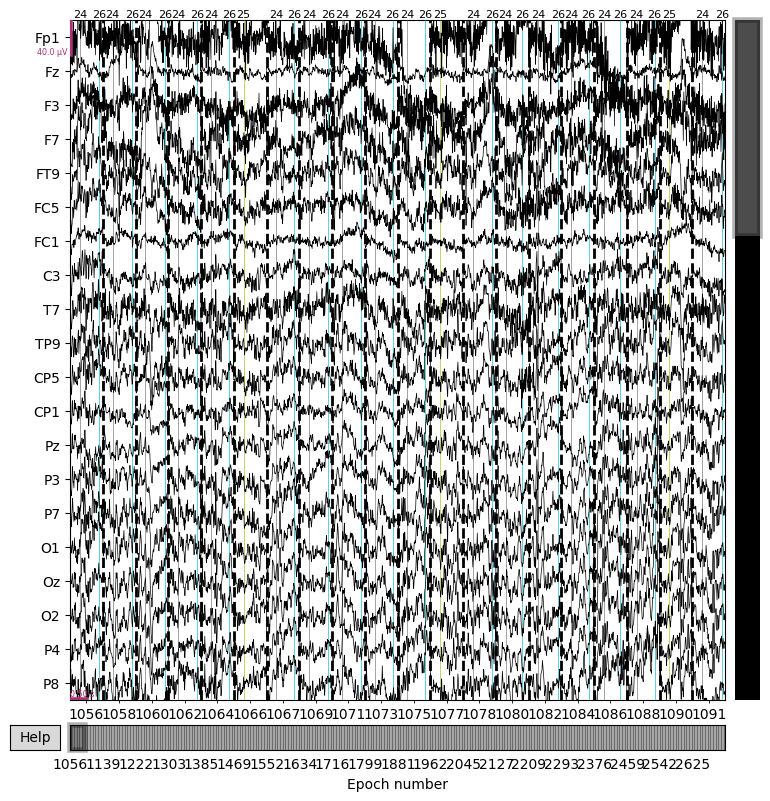

150 750 150 750
combining channels using "mean"


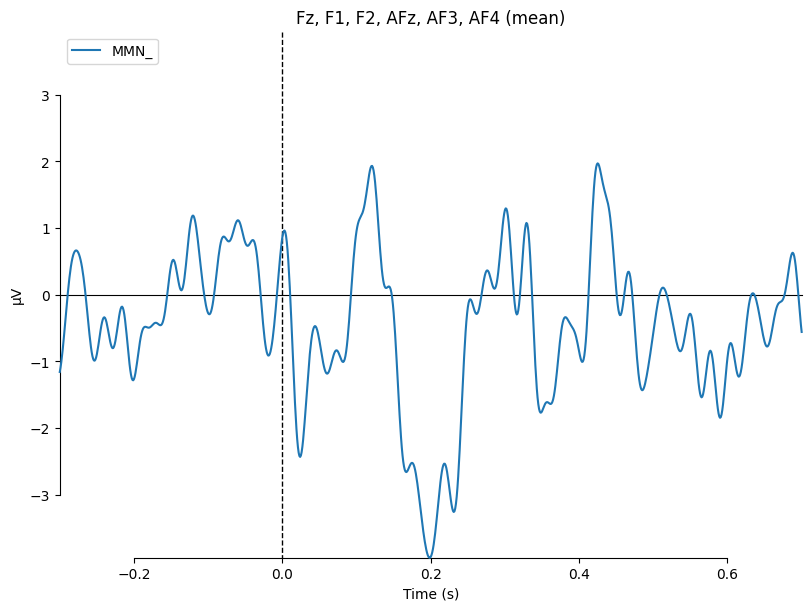

[<Figure size 800x600 with 1 Axes>]

In [2]:
import matplotlib.pyplot as plt
import numpy as np
#import pandas as pd

import mne


raw_file = r"D:\Work_data\Notification_evoked_response\Data_at_IITJ\sub007\EEG\sub007_exp2.vhdr"
raw = mne.io.read_raw_brainvision(raw_file, preload=True)

raw.plot(scalings=dict(eeg=1e-4))
raw.filter(l_freq=0.1,h_freq=40)
events,event_dict = mne.events_from_annotations(raw)

B1_epochs = mne.Epochs(raw, events, event_id=[14,15], tmin=-0.3, tmax=0.7, preload=True)
fig = B1_epochs.plot(events=events
                  )
B1_devi_eps = B1_epochs['15'].average()
B1_sta_eps = B1_epochs["14"].average()
B1_MMN_erp = mne.combine_evoked([ B1_devi_eps,B1_sta_eps], weights=[1,-1])

B2_epochs = mne.Epochs(raw, events, event_id=[24,25], tmin=-0.3, tmax=0.7, preload=True)

fig = B2_epochs.plot(events=events
                  )
B2_devi_eps = B2_epochs['25'].average()
B2_sta_eps = B2_epochs["24"].average()
B2_MMN_erp = mne.combine_evoked([ B2_devi_eps,B2_sta_eps], weights=[1,-1])

print(len(B2_epochs['25']),len(B2_epochs['24']),len(B1_epochs['15']),len(B1_epochs['14']))
#MMN_erp1 = mne.combine_evoked([ devi_eps,sta_eps], weights=[1, -1])
#MMN_er = mne.combine_evoked([ MMN_erp1,MMN_erp], weights=[1, -1])
# Campare the two contidition of deviant vs standard tone  

S07_MMN_erp = mne.combine_evoked([ B1_MMN_erp,B2_MMN_erp], weights=[1,-1])
evokeds = dict(MMN_ =S07_MMN_erp)
#picks = [n for n in range(1, 5)]
picks= ['Fz','F1','F2','AFz','AF3','AF4']
mne.viz.plot_compare_evokeds(evokeds, picks=picks, combine="mean")

combining channels using "mean"
combining channels using "mean"


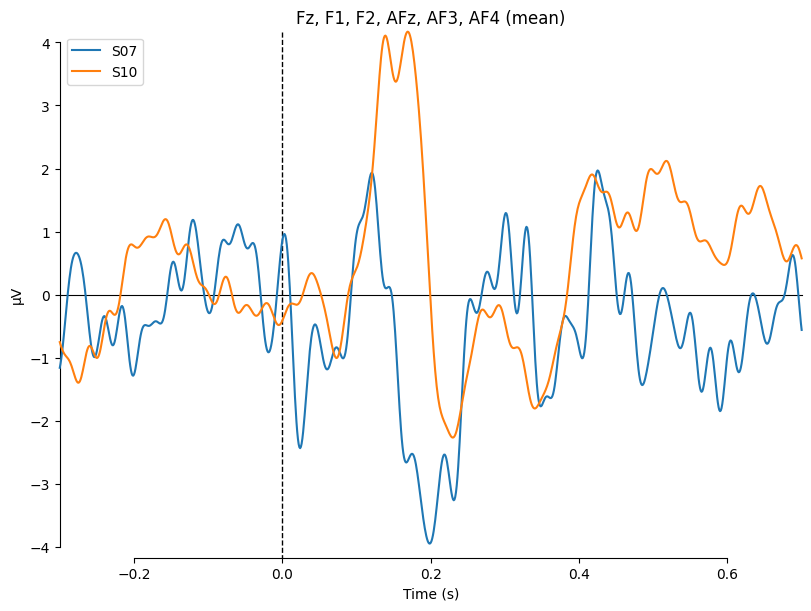

[<Figure size 800x600 with 1 Axes>]

In [3]:
evokeds = dict(S07 =S07_MMN_erp,S10=S10_MMN_erp)
#picks = [n for n in range(1, 5)]
picks= ['Fz','F1','F2','AFz','AF3','AF4']
mne.viz.plot_compare_evokeds(evokeds, picks=picks, combine="mean")

combining channels using "mean"
combining channels using "mean"


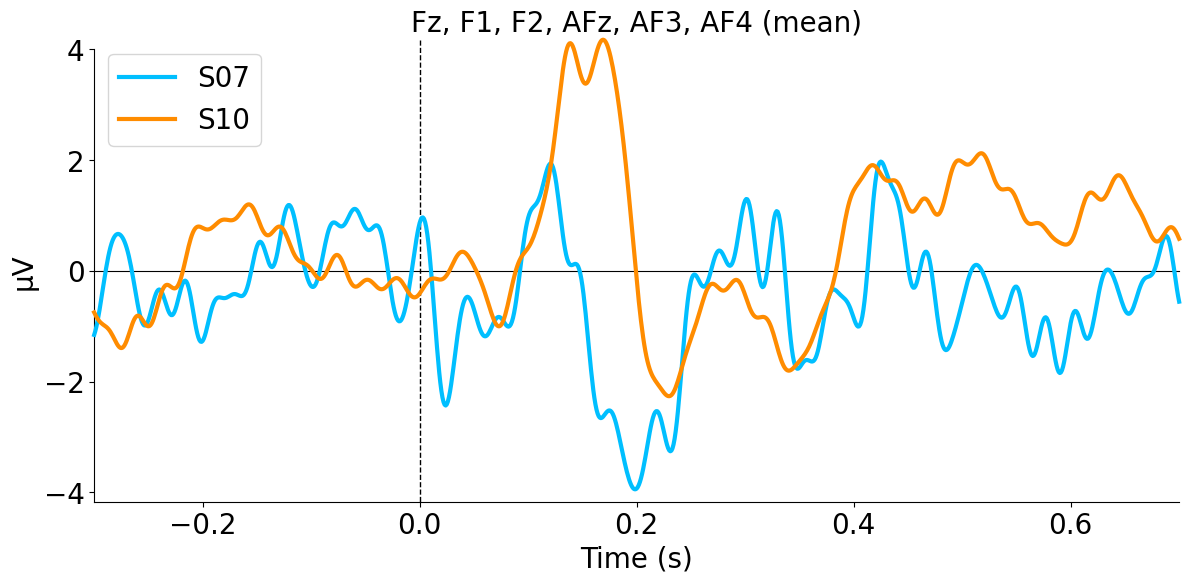

In [126]:
import mne
import matplotlib.pyplot as plt

# Assuming you have a dictionary of Evoked objects 'evokeds'
evokeds = {'S07': S07_MMN_erp, 'S10': S10_MMN_erp}

# Plot the evoked responses
fig, ax = plt.subplots(figsize=(14, 6))  # Create a figure and axis


stylesdict ={"S07": {"linewidth": 3},
             "S10": {"linewidth": 3}}
fig = mne.viz.plot_compare_evokeds(evokeds, picks=picks,colors = ['deepskyblue','darkorange'],
                                   styles=stylesdict, combine='mean',axes=ax,truncate_xaxis=False)
plt.rcParams.update({
    'xtick.labelsize': 20,  # X-axis tick labels font size
    'ytick.labelsize': 20,  # Y-axis tick labels font size
    'axes.labelsize': 20,   # Axis label font size
    'axes.titlesize': 20,   # Title font size
    'legend.fontsize': 20,   # Legend font size
})



In [14]:
print(event_dict,len(B1_epochs ["14"]))

{'Stimulus/S 11': 11, 'Stimulus/S 12': 12, 'Stimulus/S 13': 13, 'Stimulus/S 14': 14, 'Stimulus/S 15': 15, 'Stimulus/S 21': 21, 'Stimulus/S 24': 24, 'Stimulus/S 25': 25} 750


In [14]:
builtin_montages = mne.channels.get_builtin_montages(descriptions=True)
for montage_name, montage_description in builtin_montages:
    print(f"{montage_name}: {montage_description}")

standard_1005: Electrodes are named and positioned according to the international 10-05 system (343+3 locations)
standard_1020: Electrodes are named and positioned according to the international 10-20 system (94+3 locations)
standard_alphabetic: Electrodes are named with LETTER-NUMBER combinations (A1, B2, F4, …) (65+3 locations)
standard_postfixed: Electrodes are named according to the international 10-20 system using postfixes for intermediate positions (100+3 locations)
standard_prefixed: Electrodes are named according to the international 10-20 system using prefixes for intermediate positions (74+3 locations)
standard_primed: Electrodes are named according to the international 10-20 system using prime marks (' and '') for intermediate positions (100+3 locations)
biosemi16: BioSemi cap with 16 electrodes (16+3 locations)
biosemi32: BioSemi cap with 32 electrodes (32+3 locations)
biosemi64: BioSemi cap with 64 electrodes (64+3 locations)
biosemi128: BioSemi cap with 128 electrodes (1

Approximating Fpz location by mirroring Oz along the X and Y axes.


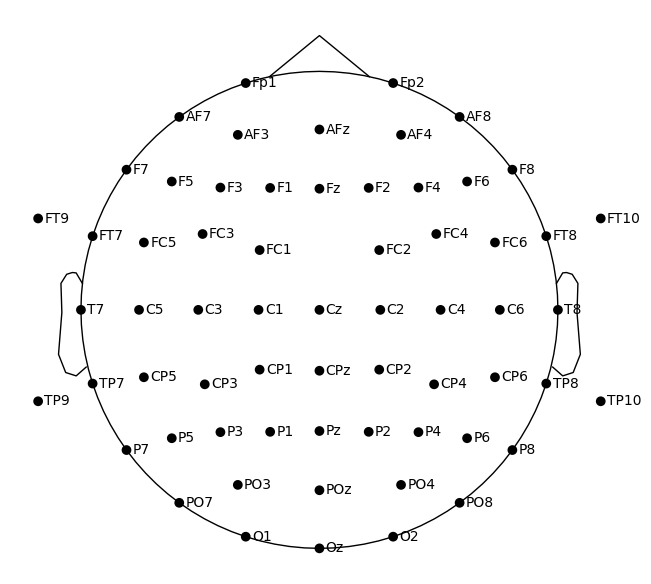

TypeError: 'Figure' object is not subscriptable

In [24]:
raw.set_montage("easycap-M1")
raw.plot_sensors(show_names=True, sphere="eeglab") 